In [ ]:
# Importing necessary libraries
import pandas as pd
from google.colab import files
import io
from IPython.display import display

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Reading the uploaded file into a pandas DataFrame
# Assuming you're uploading a CSV file
for filename in uploaded.keys():
    print(f'You uploaded file: {filename}')
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Select the first 5 and last 5 rows, then combine them with a separator
first_five = df.head()
last_five = df.tail()

# Adding a dotted separator row
separator = pd.DataFrame([["..."] * len(df.columns)], columns=df.columns)

# Combine first 5 rows, separator, and last 5 rows
display_df = pd.concat([first_five, separator, last_five], ignore_index=True)

# Step 4: Style the DataFrame with color and display it
styled_df = display_df.style.set_table_styles(
    [{'selector': 'th', 'props': [('background-color', '#5f9ea0'), ('color', 'white')]}]
).apply(lambda x: ['background-color: #d3d3d3' if x.name != '...' else '' for _ in x], axis=1)

# Display the styled DataFrame
display(styled_df)


Saving Training.csv to Training (27).csv
You uploaded file: Training (27).csv


,Date,Open,High,Low,Close
0,01-01-2014,-,-,-,17436.970000
1,02-01-2014,-,-,-,17013.870000
2,03-01-2014,-,-,-,17029.430000
3,06-01-2014,-,-,-,17030.700000
4,07-01-2014,-,-,-,16836.470000
5,...,...,...,...,...
6,25-07-2024,82373.96,83213.27,81990.24,83080.680000
7,26-07-2024,83386.53,84831.51,83301.72,84747.780000
8,29-07-2024,85298.84,85870.75,85049.22,85688.770000
9,30-07-2024,85884.85,85992.10,85366.71,85456.170000


In [ ]:
!pip install statsmodels

#**Time Series Trends**
Identify long-term trends in stock prices, indices, or other financial metrics

Saving Training.csv to Training (1).csv


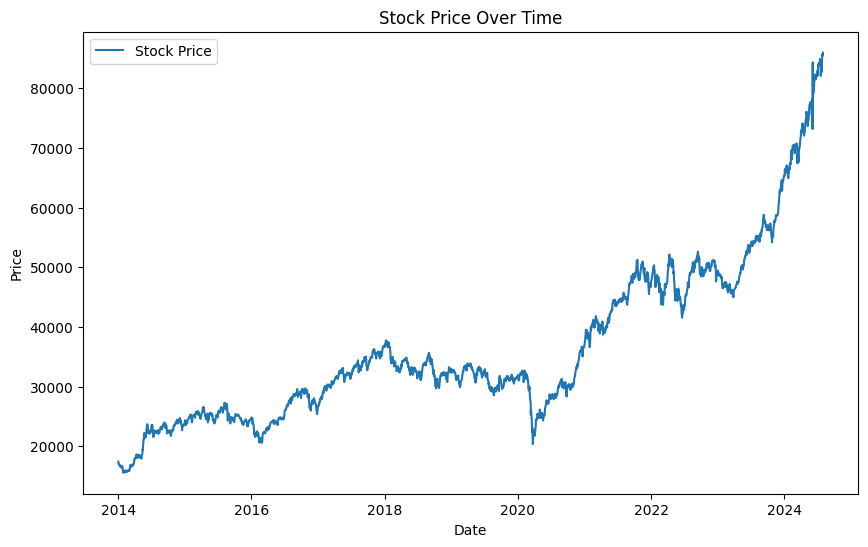

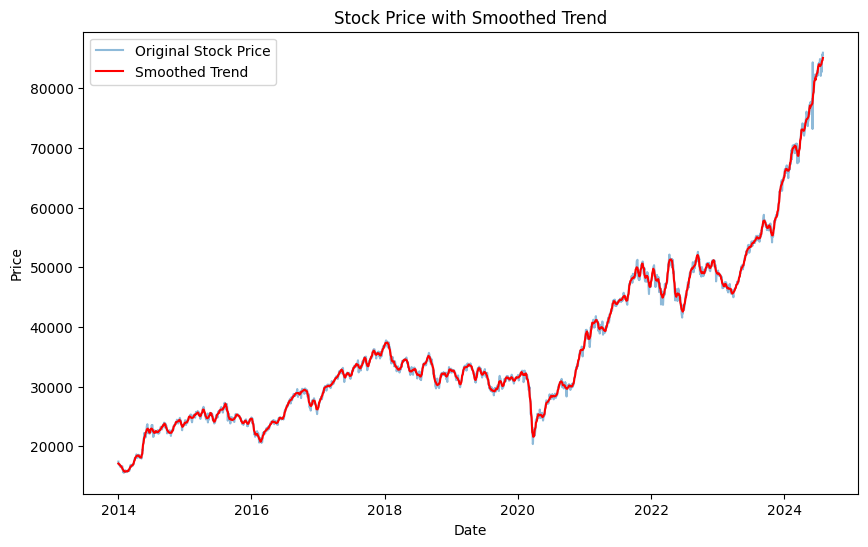

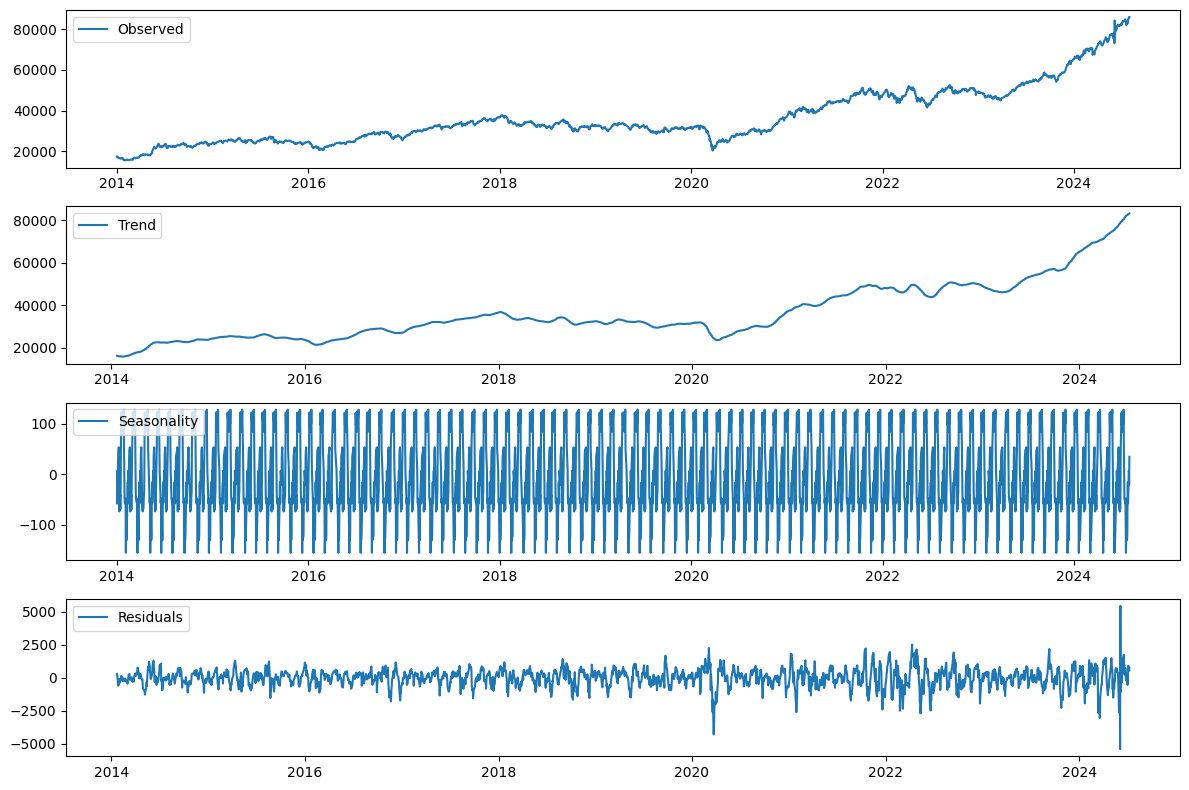

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import savgol_filter

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime, assuming the date column is in 'DD-MM-YYYY' format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Step 4: Set 'Date' as the index (important for time series)
df.set_index('Date', inplace=True)


# Step 5: Plot the stock prices (assuming the stock prices column is named 'Close')
plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Stock Price')
plt.title('Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 6: Apply a simple smoothing filter to see the long-term trend (Savgol Filter)
df['Smoothed'] = savgol_filter(df['Close'], window_length=21, polyorder=2)

# Step 7: Plot the smoothed trend
plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Original Stock Price', alpha=0.5)
plt.plot(df['Smoothed'], label='Smoothed Trend', color='red')
plt.title('Stock Price with Smoothed Trend')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Step 8: Decompose the time series into trend, seasonality, and residuals (additive model)
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)

# Step 9: Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


# **Seasonality**
Check for recurring patterns, such as quarterly earnings.


Saving Training.csv to Training (2).csv


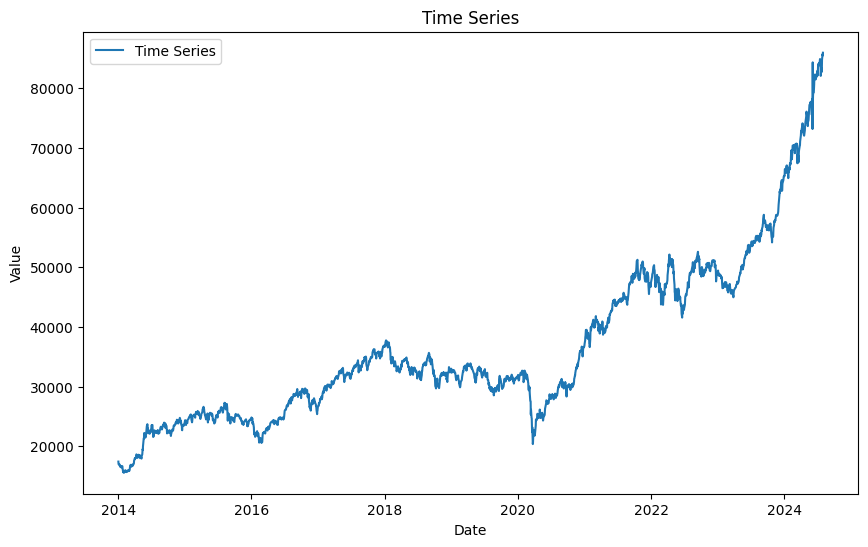

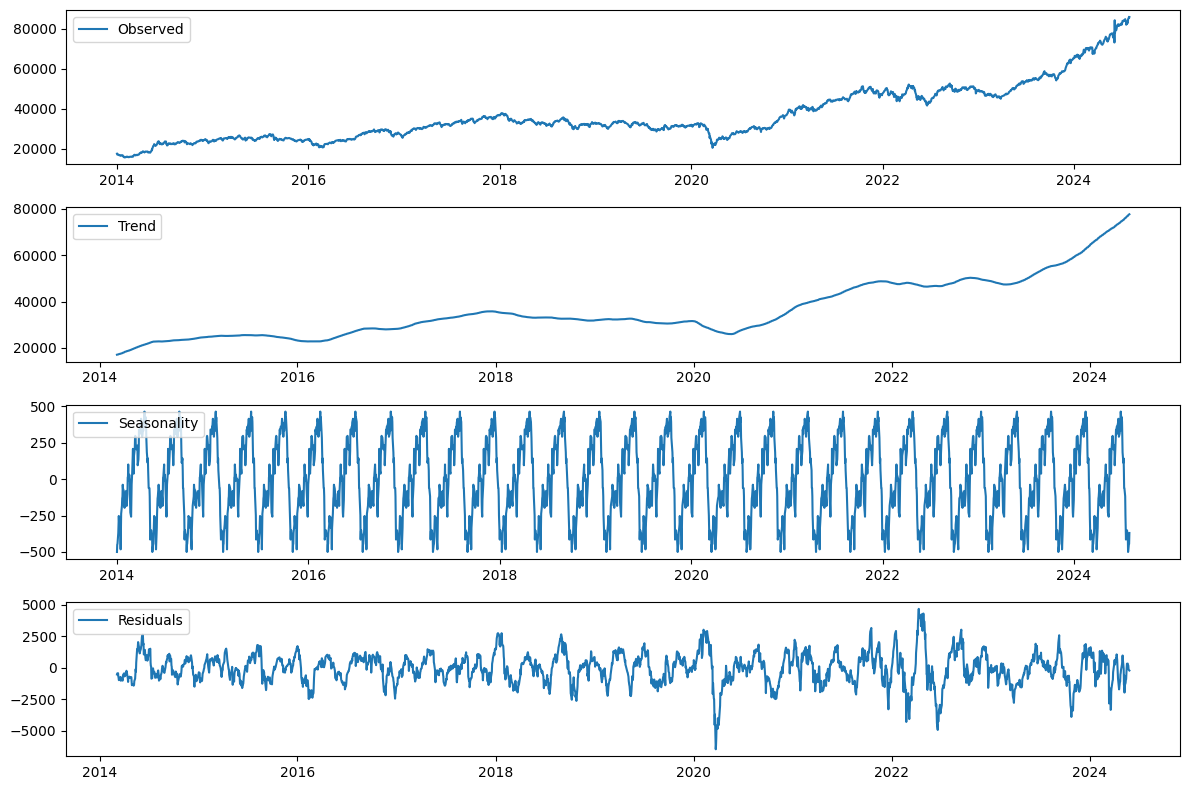

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust the format if needed

# Step 4: Set 'Date' as the index
df.set_index('Date', inplace=True)

# Step 5: Plot the time series (assuming the stock prices or earnings column is 'Close')
plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Time Series')
plt.title('Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Step 6: Decompose the time series to observe seasonality (additive model)
# Adjust the 'period' based on the frequency of the data (e.g., daily, monthly, quarterly)
decomposition = seasonal_decompose(df['Close'], model='additive', period=90)  # '90' can be adjusted for quarterly

# Step 7: Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


# **Stationarity:**
Verify if the time series has a constant mean and variance.


Saving Training.csv to Training (3).csv


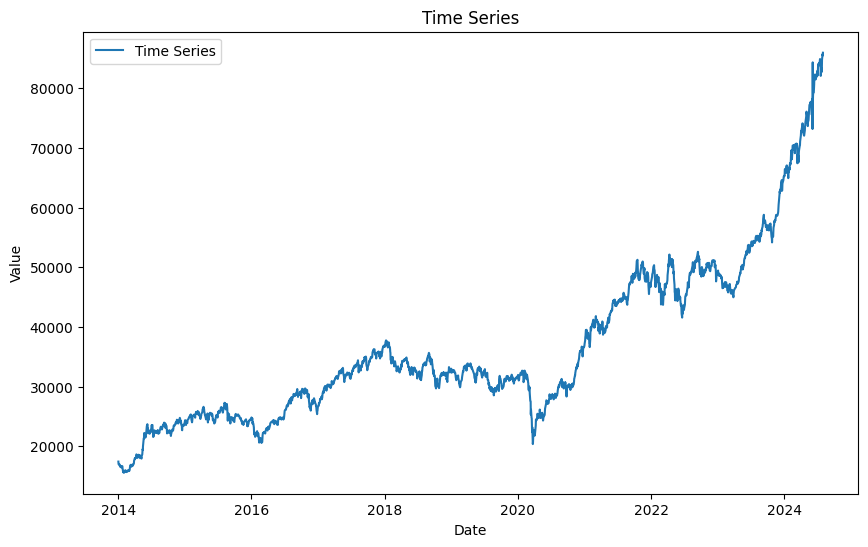

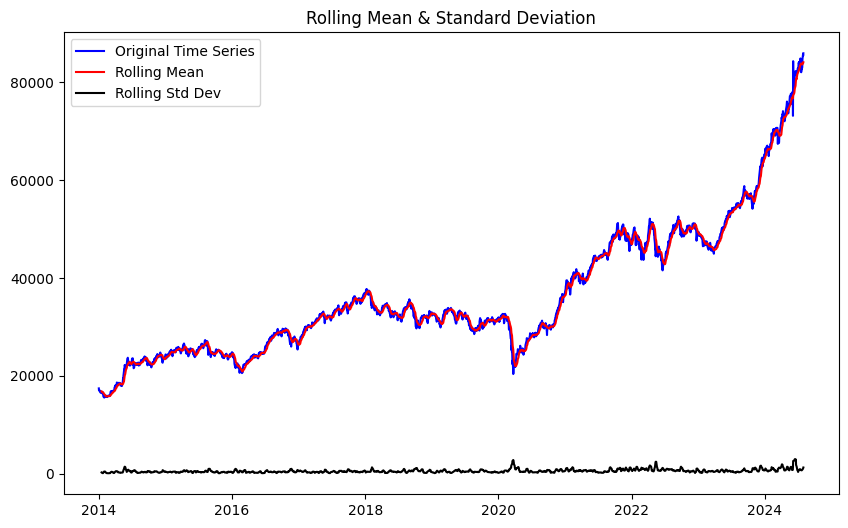

Results of ADF Test:
ADF Statistic: 2.537351
p-value: 0.999061
Critical Values:
   1%, -3.432856986061305
Critical Values:
   5%, -2.8626475938238967
Critical Values:
   10%, -2.5673596115790938


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust the format if needed

# Step 4: Set 'Date' as the index
df.set_index('Date', inplace=True)

# Step 5: Plot the time series to observe mean and variance visually (assuming column 'Close')
plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Time Series')
plt.title('Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# Step 6: Calculate and plot rolling statistics (rolling mean and standard deviation)
rolling_mean = df['Close'].rolling(window=12).mean()  # Window size can be adjusted
rolling_std = df['Close'].rolling(window=12).std()

plt.figure(figsize=(10, 6))
plt.plot(df['Close'], label='Original Time Series', color='blue')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std Dev', color='black')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.show()

# Step 7: Perform Augmented Dickey-Fuller (ADF) test for stationarity
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print('Critical Values:')
        print(f'   {key}, {value}')

# Apply the ADF test
print('Results of ADF Test:')
adf_test(df['Close'])


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust the format if needed

# Step 4: Set 'Date' as the index
df.set_index('Date', inplace=True)

# Step 5: Display basic descriptive statistics for 'Close' column
print("Descriptive Statistics for 'Close' Price:")
print(df['Close'].describe())  # This will show count, mean, std, min, 25%, 50%, 75%, max

# Step 6: Calculate and print specific metrics
mean_value = df['Close'].mean()
variance_value = df['Close'].var()
percentile_25 = np.percentile(df['Close'], 25)
percentile_75 = np.percentile(df['Close'], 75)
median_value = df['Close'].median()
std_dev = df['Close'].std()

print("\nAdditional Statistics:")
print(f"Mean: {mean_value}")
print(f"Variance: {variance_value}")
print(f"25th Percentile: {percentile_25}")
print(f"75th Percentile: {percentile_75}")
print(f"Median: {median_value}")
print(f"Standard Deviation: {std_dev}")


Saving Training.csv to Training (4).csv
Descriptive Statistics for 'Close' Price:
count     2614.00000
mean     36585.49759
std      13743.31637
min      15574.85000
25%      26334.85000
50%      32369.58000
75%      45937.80500
max      85930.29000
Name: Close, dtype: float64

Additional Statistics:
Mean: 36585.49758990053
Variance: 188878744.8323953
25th Percentile: 26334.85
75th Percentile: 45937.805
Median: 32369.58
Standard Deviation: 13743.316369508319


# **Correlation:**
Analyze relationships between variables, like stock prices and trading volume.


Saving Training.csv to Training (5).csv


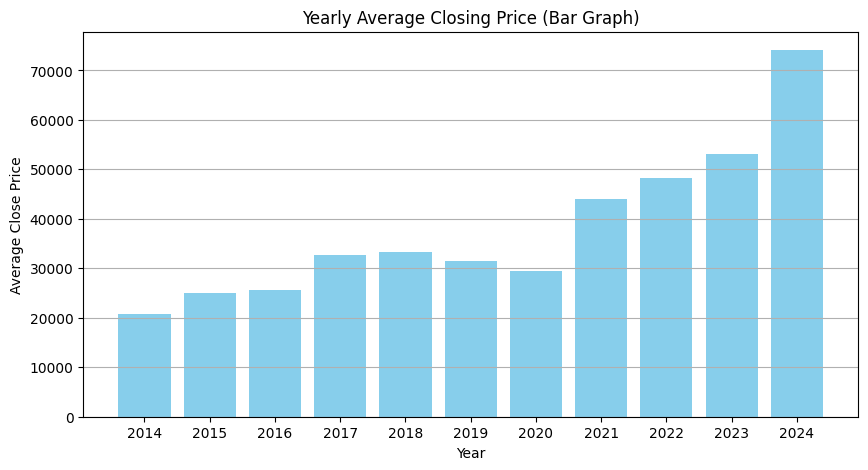

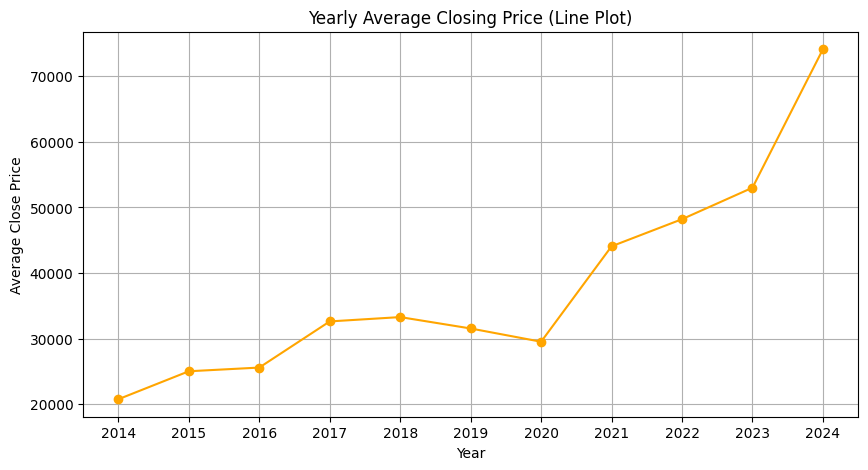

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust format if needed

# Step 4: Extract year from the Date column and create a new column
df['Year'] = df['Date'].dt.year

# Step 5: Group by Year and calculate the mean closing price
yearly_close = df.groupby('Year')['Close'].mean().reset_index()

# Step 6: Create a bar graph for yearly average closing prices
plt.figure(figsize=(10, 5))
plt.bar(yearly_close['Year'], yearly_close['Close'], color='skyblue')
plt.title('Yearly Average Closing Price (Bar Graph)')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.xticks(yearly_close['Year'])  # Show all years on the x-axis
plt.grid(axis='y')
plt.show()

# Step 7: Create a line plot for yearly average closing prices
plt.figure(figsize=(10, 5))
plt.plot(yearly_close['Year'], yearly_close['Close'], marker='o', color='orange')
plt.title('Yearly Average Closing Price (Line Plot)')
plt.xlabel('Year')
plt.ylabel('Average Close Price')
plt.xticks(yearly_close['Year'])  # Show all years on the x-axis
plt.grid()
plt.show()


Saving Training.csv to Training (6).csv


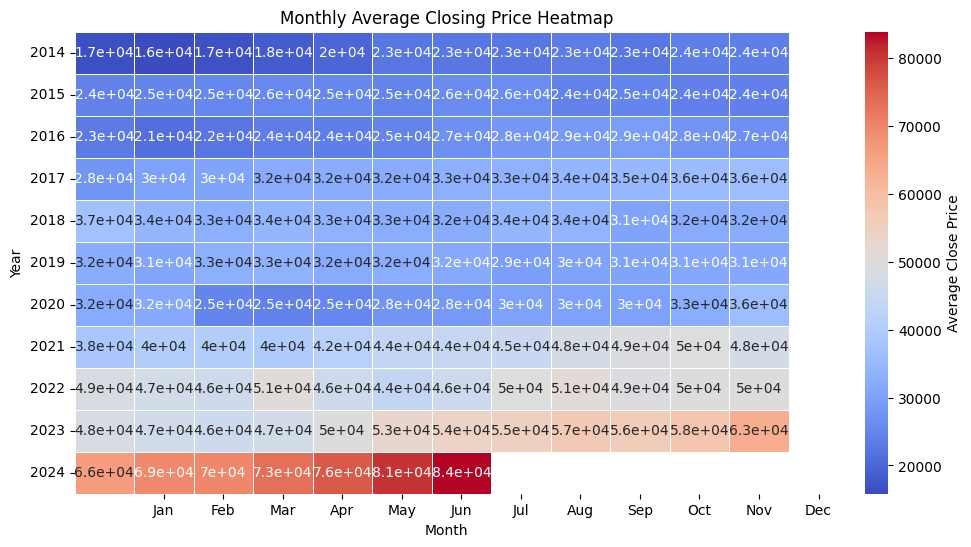

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust format if needed

# Step 4: Extract year and month from the Date column and create new columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Step 5: Group by Year and Month, then calculate the mean closing price
monthly_close = df.groupby(['Year', 'Month'])['Close'].mean().reset_index()

# Step 6: Pivot the DataFrame for heatmap (Years as rows, Months as columns)
heatmap_data = monthly_close.pivot(index='Year', columns='Month', values='Close')

# Step 7: Plot heatmap of the monthly closing prices
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, cbar_kws={'label': 'Average Close Price'})
plt.title('Monthly Average Closing Price Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=np.arange(1.5, 13.5), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.yticks(rotation=0)
plt.show()


Saving Training.csv to Training (7).csv


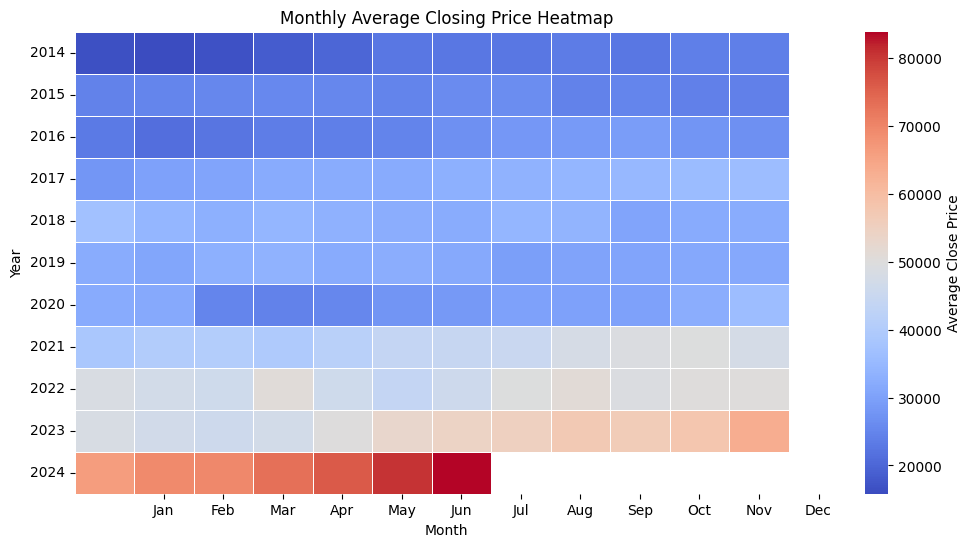

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Upload the dataset
uploaded = files.upload()

# Step 2: Read the dataset
for filename in uploaded.keys():
    df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')))

# Step 3: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjust format if needed

# Step 4: Extract year and month from the Date column and create new columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Step 5: Group by Year and Month, then calculate the mean closing price
monthly_close = df.groupby(['Year', 'Month'])['Close'].mean().reset_index()

# Step 6: Pivot the DataFrame for heatmap (Years as rows, Months as columns)
heatmap_data = monthly_close.pivot(index='Year', columns='Month', values='Close')

# Step 7: Plot heatmap of the monthly closing prices without annotations
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, cmap="coolwarm", linewidths=0.5, cbar_kws={'label': 'Average Close Price'})
plt.title('Monthly Average Closing Price Heatmap')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=np.arange(1.5, 13.5), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.yticks(rotation=0)
plt.show()


Saving Training.csv to Training (17).csv


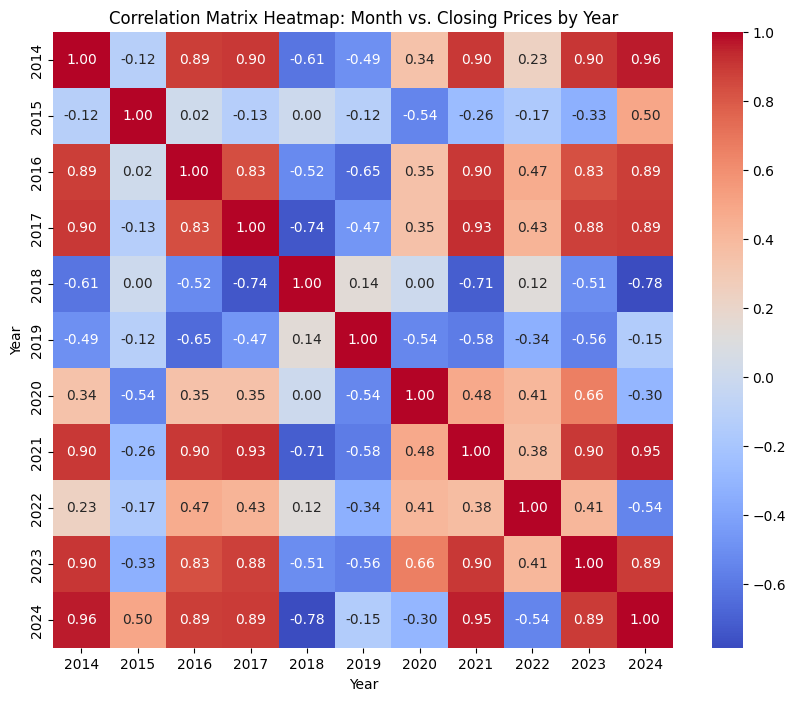

In [ ]:
# Step 1: Install required libraries (if not already installed)
#!pip install seaborn

# Step 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Step 3: Upload your dataset
uploaded = files.upload()

# Step 4: Load the dataset into a Pandas DataFrame
df = pd.read_csv(next(iter(uploaded)))

# Step 5: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjusting format to DD-MM-YYYY if needed

# Step 6: Convert 'Close' column to numeric, forcing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Step 7: Drop rows with NaN values in 'Close'
df = df.dropna(subset=['Close'])

# Step 8: Extract the Month and Year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Step 9: Create a grouped DataFrame for average closing prices by Month and Year
grouped_data = df.groupby(['Year', 'Month'])['Close'].mean().reset_index()

# Step 10: Pivot the data for correlation analysis
pivot_table = grouped_data.pivot(index='Month', columns='Year', values='Close')

# Step 11: Calculate the correlation matrix
correlation_matrix = pivot_table.corr()

# Step 12: Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', cbar=True, fmt=".2f")
plt.title('Correlation Matrix Heatmap: Month vs. Closing Prices by Year')
plt.xlabel('Year')
plt.ylabel('Year')
plt.show()


# **VOLATILITY**

Saving Training.csv to Training (19).csv


<ipython-input-21-964f9c6bcbfb>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility_data, x='Year', y='Volatility', palette='viridis')


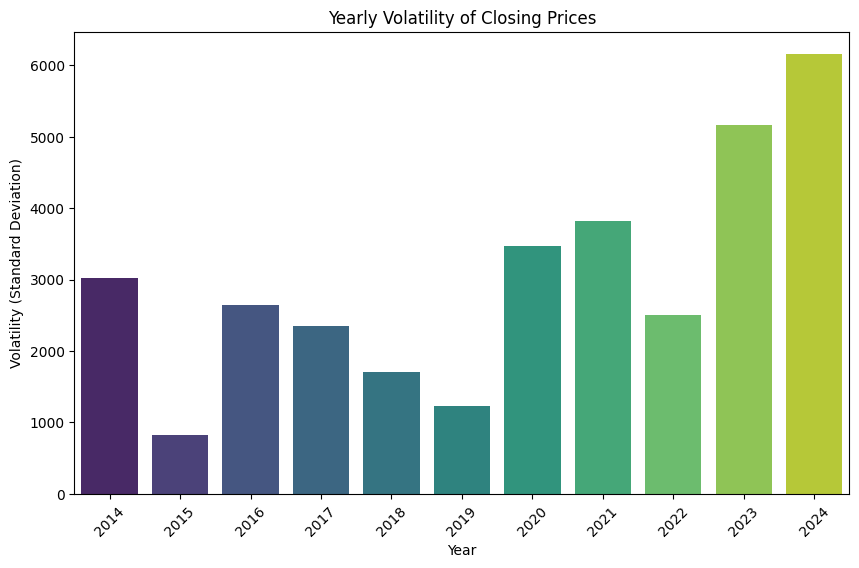

    Year   Volatility
0   2014  3019.895577
1   2015   830.193432
2   2016  2644.048680
3   2017  2348.901187
4   2018  1703.358822
5   2019  1229.162268
6   2020  3473.325034
7   2021  3816.455652
8   2022  2503.936834
9   2023  5161.986350
10  2024  6157.721972


In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install seaborn

# Step 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Step 3: Upload your dataset
uploaded = files.upload()

# Step 4: Load the dataset into a Pandas DataFrame
df = pd.read_csv(next(iter(uploaded)))

# Step 5: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjusting format to DD-MM-YYYY if needed

# Step 6: Convert 'Close' column to numeric, forcing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Step 7: Drop rows with NaN values in 'Close'
df = df.dropna(subset=['Close'])

# Step 8: Extract the Year from the 'Date' column
df['Year'] = df['Date'].dt.year

# Step 9: Calculate the volatility (standard deviation) of closing prices by Year
volatility_data = df.groupby('Year')['Close'].std().reset_index()

# Step 10: Rename the standard deviation column to 'Volatility'
volatility_data.rename(columns={'Close': 'Volatility'}, inplace=True)

# Step 11: Plot the volatility data
plt.figure(figsize=(10, 6))
sns.barplot(data=volatility_data, x='Year', y='Volatility', palette='viridis')
plt.title('Yearly Volatility of Closing Prices')
plt.xlabel('Year')
plt.ylabel('Volatility (Standard Deviation)')
plt.xticks(rotation=45)
plt.show()

# Step 12: Display the volatility data for review
print(volatility_data)


Saving Training.csv to Training (20).csv


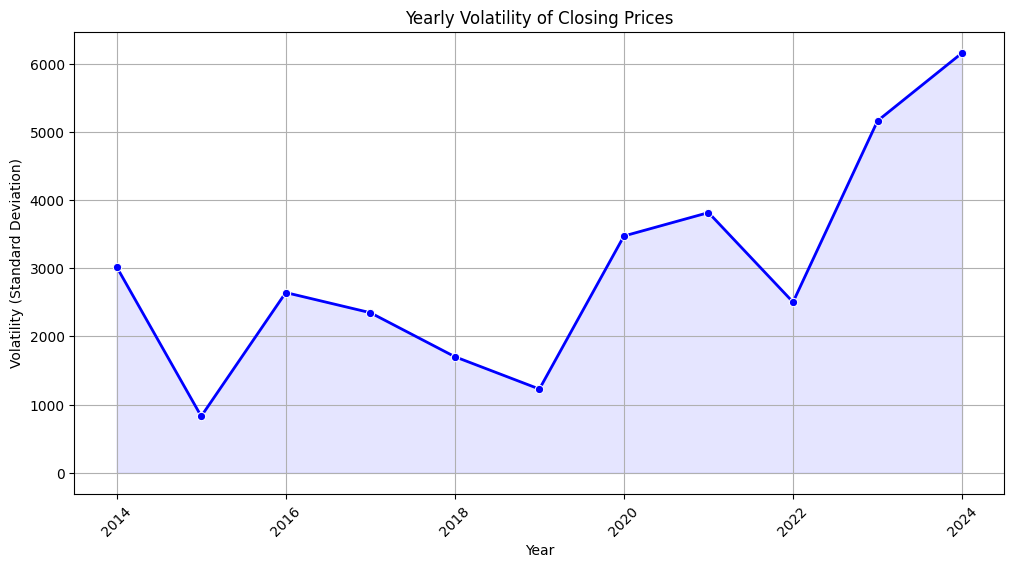

    Year   Volatility
0   2014  3019.895577
1   2015   830.193432
2   2016  2644.048680
3   2017  2348.901187
4   2018  1703.358822
5   2019  1229.162268
6   2020  3473.325034
7   2021  3816.455652
8   2022  2503.936834
9   2023  5161.986350
10  2024  6157.721972


In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install seaborn

# Step 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Step 3: Upload your dataset
uploaded = files.upload()

# Step 4: Load the dataset into a Pandas DataFrame
df = pd.read_csv(next(iter(uploaded)))

# Step 5: Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')  # Adjusting format to DD-MM-YYYY if needed

# Step 6: Convert 'Close' column to numeric, forcing errors to NaN
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Step 7: Drop rows with NaN values in 'Close'
df = df.dropna(subset=['Close'])

# Step 8: Extract the Year from the 'Date' column
df['Year'] = df['Date'].dt.year

# Step 9: Calculate the volatility (standard deviation) of closing prices by Year
volatility_data = df.groupby('Year')['Close'].std().reset_index()

# Step 10: Rename the standard deviation column to 'Volatility'
volatility_data.rename(columns={'Close': 'Volatility'}, inplace=True)

# Step 11: Plotting a Line Plot for Volatility
plt.figure(figsize=(12, 6))
sns.lineplot(data=volatility_data, x='Year', y='Volatility', marker='o', color='blue', linewidth=2)
plt.title('Yearly Volatility of Closing Prices')
plt.xlabel('Year')
plt.ylabel('Volatility (Standard Deviation)')
plt.xticks(rotation=45)
plt.grid(True)
plt.fill_between(volatility_data['Year'], volatility_data['Volatility'], color='blue', alpha=0.1)  # Optional fill under line
plt.show()

# Step 12: Display the volatility data for review
print(volatility_data)


# **EMPTY DATA**

Saving Training.csv to Training (23).csv


<ipython-input-25-7332b977298d>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Open'].replace('-', pd.NA, inplace=True)


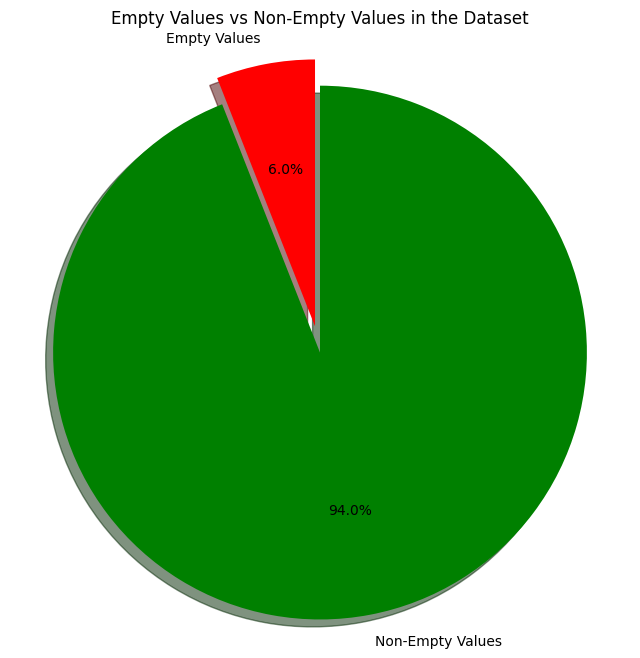

Total Empty Values: 781
Total Non-Empty Values: 12289


In [ ]:
# Step 1: Install required libraries (if not already installed)
!pip install seaborn

# Step 2: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 3: Upload your dataset
uploaded = files.upload()

# Step 4: Load the dataset into a Pandas DataFrame
df = pd.read_csv(next(iter(uploaded)))

# Step 5: Replace '-' with NaN in the 'Open' column
df['Open'].replace('-', pd.NA, inplace=True)

# Step 6: Convert the 'Open' column to numeric
df['Open'] = pd.to_numeric(df['Open'], errors='coerce')

# Step 7: Calculate total empty values and non-empty values across the entire dataset
total_empty = df.isnull().sum().sum()  # Total empty values across all columns
total_non_empty = df.notnull().sum().sum()  # Total non-empty values across all columns

# Step 8: Prepare data for the pie chart
labels = ['Empty Values', 'Non-Empty Values']
sizes = [total_empty, total_non_empty]
colors = ['red', 'green']
explode = (0.1, 0)  # explode 1st slice (Empty Values)

# Step 9: Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Empty Values vs Non-Empty Values in the Dataset')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Step 10: Display the value counts for review
print(f'Total Empty Values: {total_empty}')
print(f'Total Non-Empty Values: {total_non_empty}')
